# Chapter 42 lab — AI and Neuroscience (Python)

In this lab you will build the two computational bridges between artificial and biological networks described in Chapter 42, using nothing but numpy — no deep learning frameworks required. **Part 1** simulates error-driven learning with the Rescorla–Wagner and temporal difference (TD) models and shows that the TD prediction error reproduces the classic phasic dopamine signal: a burst to unexpected reward that *transfers to the predictive cue* with learning, and a dip when expected reward is omitted. **Part 2** is a toy representational similarity analysis (RSA): we train a tiny multilayer network with hand-coded backpropagation and show that *training for a task* is what makes a layer's representational geometry match a category-coding "brain region" — the logic of the Yamins et al. experiment in Figure 42.3 of the book.

**How to run this notebook:** it runs anywhere — directly in your browser on the tutorial site, on Google Colab, or locally (only numpy, scipy, and matplotlib are needed). Run cells top to bottom. For background and the chapter text, see the [chapter page](../ch42-ai-and-neuroscience.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 90

## Part 1 — Prediction errors and dopamine

### 1.1 The Rescorla–Wagner model

The Rescorla–Wagner (RW) model is the simplest form of value-based, error-driven learning. The agent maintains a value estimate $V$ for a cue, and updates it after each trial in proportion to the **prediction error** $\delta$ — the mismatch between the reward received and the reward expected:

$$V_{t+1} = V_t + \alpha\,\delta_t, \qquad \delta_t = R_t - V_t$$

The learning rate $\alpha$ controls how quickly $V$ tracks recent outcomes. We simulate a conditioning experiment: a cue is followed by reward on 80% of trials for 80 trials (**acquisition**), then reward stops (**extinction**).

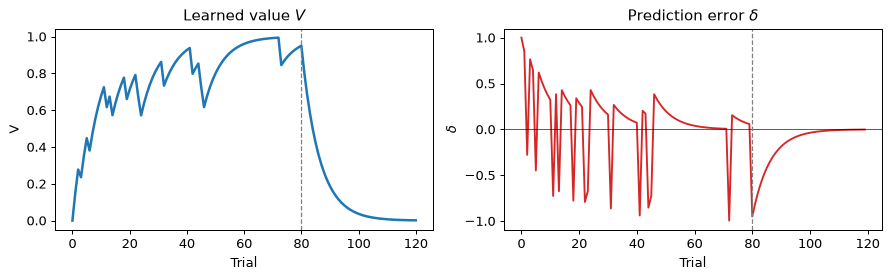

In [2]:
# Rescorla-Wagner: acquisition then extinction
# Adapted from the CANlab Computational Foundations course (github.com/canlab)
alpha, n_trials = 0.15, 120
r = (rng.random(n_trials) < 0.8).astype(float)  # cue -> reward on 80% of trials
r[80:] = 0.0                                    # extinction after trial 80

V = np.zeros(n_trials + 1)                      # value estimate
pe = np.zeros(n_trials)                         # prediction errors
for t in range(n_trials):
    pe[t] = r[t] - V[t]                         # prediction error (dopamine-like)
    V[t + 1] = V[t] + alpha * pe[t]             # value update

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(V, lw=2, color="tab:blue")
ax[0].axvline(80, color="gray", ls="--", lw=1)
ax[0].set(title="Learned value $V$", xlabel="Trial", ylabel="V")
ax[1].plot(pe, color="tab:red")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].axvline(80, color="gray", ls="--", lw=1)
ax[1].set(title=r"Prediction error $\delta$", xlabel="Trial", ylabel=r"$\delta$")
fig.tight_layout()

**Interpretation.** Early in acquisition, rewards are unexpected, so prediction errors are large and positive and $V$ climbs toward the true reward rate (0.8). As $V$ converges, rewarded trials produce small positive errors and unrewarded trials small negative ones — the errors *shrink as learning proceeds*. At extinction (dashed line) every trial delivers less than expected, producing a run of negative prediction errors that drives $V$ back toward zero. If $\delta$ were a neuron's firing (relative to baseline), you would see bursts early in learning and dips at extinction — already qualitatively dopamine-like.

### 1.2 The learning rate shapes the value trajectory

$\alpha$ trades speed against stability. This single parameter, fitted to a participant's choices, is a workhorse of computational psychiatry.

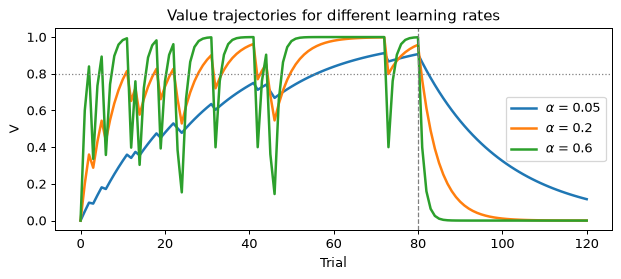

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for a in (0.05, 0.2, 0.6):
    Va = np.zeros(n_trials + 1)
    for t in range(n_trials):
        Va[t + 1] = Va[t] + a * (r[t] - Va[t])
    ax.plot(Va, lw=2, label=f"$\\alpha$ = {a}")
ax.axvline(80, color="gray", ls="--", lw=1)
ax.axhline(0.8, color="gray", ls=":", lw=1)
ax.set(title="Value trajectories for different learning rates",
       xlabel="Trial", ylabel="V")
ax.legend()
fig.tight_layout()

A small $\alpha$ learns slowly but averages over many outcomes (a smooth trajectory hugging the true rate); a large $\alpha$ chases each recent outcome (fast but volatile, and fast to extinguish). With $\alpha = 1$, the expectation would simply equal the last reward.

### 1.3 Temporal difference learning: the dopamine signal moves to the cue

The RW model updates one value per *trial*. Real dopamine neurons respond at specific *moments within* a trial — and their hallmark behavior is that, with learning, the reward burst disappears and a burst appears at the earliest predictive **cue**. Temporal difference (TD) learning captures this by assigning a value $V(s_t)$ to each time step within the trial, with the error comparing each moment's prediction against the reward received plus the discounted prediction one step later:

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

We simulate a trial as a chain of time steps: a brief inter-trial interval (ITI), a **cue** at step 3, and a **reward** at step 13. Because the cue's *onset* is unpredictable, the ITI states keep value 0 (we do not update them); the jump from 0 to $V(\text{cue})$ is itself a prediction error — this is what produces the persistent cue response.

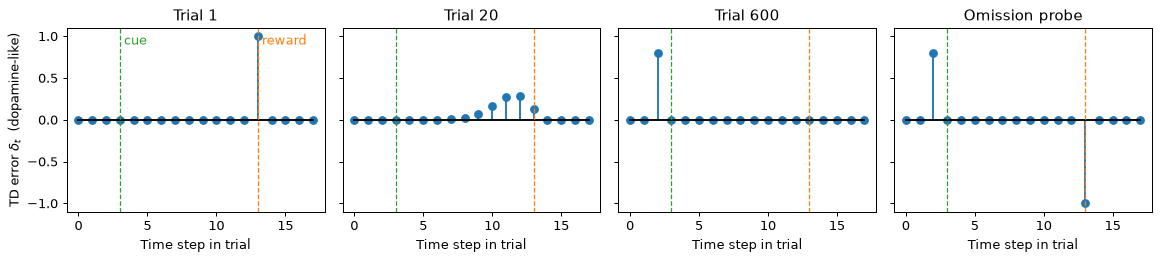

In [4]:
T, cue, rew = 18, 3, 13          # states within a trial; cue and reward times
gamma, alpha_td, n_train = 0.98, 0.10, 600

r_trial = np.zeros(T)
r_trial[rew] = 1.0

V = np.zeros(T + 1)              # V[T] = 0 (end of trial)
deltas = np.zeros((n_train, T))
for trial in range(n_train):
    for t in range(T):
        d = r_trial[t] + gamma * V[t + 1] - V[t]
        deltas[trial, t] = d
        if t >= cue:             # ITI states stay at 0: cue onset is unpredictable
            V[t] += alpha_td * d

# Probe trial with reward OMITTED (no learning, just measure the error)
delta_omit = np.array([0.0 + gamma * V[t + 1] - V[t] for t in range(T)])

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, (lab, d) in zip(axes, [("Trial 1", deltas[0]), ("Trial 20", deltas[19]),
                               ("Trial 600", deltas[-1]), ("Omission probe", delta_omit)]):
    ax.stem(np.arange(T), d, basefmt="k-")
    ax.axvline(cue, color="tab:green", ls="--", lw=1)
    ax.axvline(rew, color="tab:orange", ls="--", lw=1)
    ax.set(title=lab, xlabel="Time step in trial")
axes[0].set_ylabel(r"TD error $\delta_t$  (dopamine-like)")
axes[0].text(cue + 0.3, 0.9, "cue", color="tab:green")
axes[0].text(rew + 0.3, 0.9, "reward", color="tab:orange")
fig.tight_layout()

**This is the Schultz result, in 20 lines of numpy.** Early in training (Trial 1), the prediction error occurs at the *reward*: the burst signals unexpected reward. As learning propagates value backward through the state chain (Trial 20), the error shrinks at the reward and marches earlier in time. After training (Trial 600), the reward itself evokes almost no error — the burst has **transferred to the cue**, whose unpredictable onset still carries surprise (it is plotted at the ITI-to-cue transition, one step before the dashed cue line: the moment the cue appears). And when a fully predicted reward is omitted (right panel), the error at the expected reward time is *negative* — a dip below baseline, exactly as dopamine neurons pause when an expected reward fails to arrive.

In **model-based fMRI**, trial-by-trial quantities like $\delta_t$ from a model fitted to behavior are used as parametric regressors (Chapter 20), and BOLD responses in the ventral striatum — a major dopamine target — reliably track them. Keep the limits in mind, though: BOLD is not dopamine, phasic and tonic signals mix, and the mapping is an analogy at the level of *computation*, not a measurement of the neurotransmitter.

## Part 2 — Toy representational similarity analysis

### 2.1 The logic

Representational similarity analysis (RSA) compares two systems at the level of representational *geometry*. For a set of stimuli, compute each system's **representational dissimilarity matrix (RDM)** — the matrix of pairwise dissimilarities (here, $1 - $ correlation) between the response patterns the stimuli evoke. Two systems with completely different units (network nodes vs. voxels) can then be compared by correlating their RDMs. In Figure 42.3 of the book, the top layer of a performance-optimized CNN reproduces the category structure of IT cortex RDMs.

Here we build the whole pipeline in miniature:

1. **Stimuli:** 32 items = 4 categories × 8 exemplars, each a 20-dimensional feature vector (a deliberately *weak* category prototype buried under large exemplar-specific variation).
2. **Two simulated "brain regions":** an *early sensory* region whose responses linearly mix the raw stimulus features, and a *category-selective* region whose responses code category identity — each measured with noise.
3. **A tiny neural network** (20 → 12 → 4) trained by backpropagation to classify the categories. We compare the RDMs of its layers — the hidden layer *before* and *after* training, and the trained output layer — with each brain region.

Stimuli are ordered by category (8 per category).


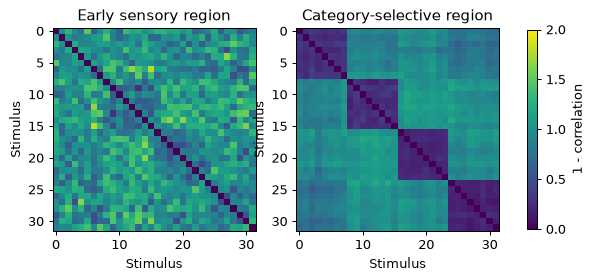

In [5]:
n_cat, n_ex = 4, 8
n_stim = n_cat * n_ex
n_feat = 20
categ = np.repeat(np.arange(n_cat), n_ex)          # category labels

protos = rng.standard_normal((n_cat, n_feat))      # category prototypes
X = 0.6 * protos[categ] + 1.6 * rng.standard_normal((n_stim, n_feat))
# ^ weak category signal, buried under exemplar-specific variation

# Simulated brain regions (60 "voxels" each)
early_region = X @ rng.standard_normal((n_feat, 60)) \
               + 2.0 * rng.standard_normal((n_stim, 60))       # mixes raw features
onehot = np.eye(n_cat)[categ]
categ_region = 4.0 * onehot @ rng.standard_normal((n_cat, 60)) \
               + 2.0 * rng.standard_normal((n_stim, 60))       # codes category

def rdm(A):
    '''Correlation-distance RDM: 1 - Pearson correlation between item patterns.'''
    return 1 - np.corrcoef(A)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
for a, (name, R) in zip(ax, [("Early sensory region", rdm(early_region)),
                             ("Category-selective region", rdm(categ_region))]):
    im = a.imshow(R, cmap="viridis", vmin=0, vmax=2)
    a.set(title=name, xlabel="Stimulus", ylabel="Stimulus")
fig.colorbar(im, ax=ax, shrink=0.8, label="1 - correlation")
print("Stimuli are ordered by category (8 per category).")

The category-selective region shows the classic **block-diagonal** RDM: items from the same category evoke similar patterns (dark blocks), items from different categories dissimilar ones. The early region's RDM instead reflects idiosyncratic feature similarity between individual exemplars — faint category structure at best, because exemplar variation dominates the raw features.

### 2.2 A tiny network, trained with hand-coded backpropagation

The network is deliberately minimal: one hidden layer of 12 ReLU units and a softmax output over the 4 categories, trained by full-batch gradient descent on the cross-entropy loss (plus a little weight decay, which encourages the network to discard input directions it does not need). This is the same algorithm — loss, gradient, backpropagation, weight update — that trains networks with billions of parameters.

final training accuracy: 100%   final loss: 0.004


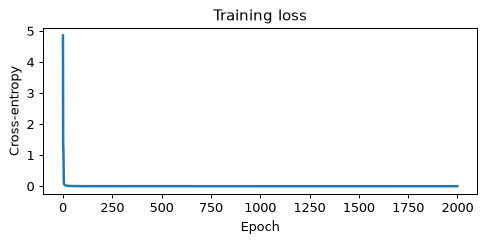

In [6]:
n_hidden, n_epochs, lr, wd = 12, 2000, 0.5, 3e-3
Y = np.eye(n_cat)[categ]                            # one-hot targets

W1 = 0.5 * rng.standard_normal((n_feat, n_hidden)); b1 = np.zeros(n_hidden)
W2 = 0.5 * rng.standard_normal((n_hidden, n_cat));  b2 = np.zeros(n_cat)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = np.maximum(Z1, 0)                          # ReLU hidden layer
    S = A1 @ W2 + b2
    P = np.exp(S - S.max(1, keepdims=True))
    P /= P.sum(1, keepdims=True)                    # softmax class probabilities
    return Z1, A1, P

hidden_untrained = forward(X, W1, b1, W2, b2)[1]    # hidden layer BEFORE training

losses = []
for epoch in range(n_epochs):
    Z1, A1, P = forward(X, W1, b1, W2, b2)
    losses.append(-np.mean(np.sum(Y * np.log(P + 1e-12), axis=1)))
    dS = (P - Y) / n_stim                           # backpropagation
    dW2 = A1.T @ dS + wd * W2;   db2 = dS.sum(0)
    dA1 = dS @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X.T @ dZ1 + wd * W1;   db1 = dZ1.sum(0)
    W2 -= lr * dW2; b2 -= lr * db2                  # gradient descent step
    W1 -= lr * dW1; b1 -= lr * db1

_, hidden_trained, output_trained = forward(X, W1, b1, W2, b2)  # AFTER training
acc = np.mean(output_trained.argmax(1) == categ)
print(f"final training accuracy: {acc:.0%}   final loss: {losses[-1]:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.plot(losses, lw=2)
ax.set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy")
fig.tight_layout()

### 2.3 Compare the model's RDMs to the brain regions'

Now the RSA step: compute RDMs for the raw input features, the untrained hidden layer, the trained hidden layer, and the trained output layer, and correlate each (Spearman correlation of the off-diagonal entries) with each brain region's RDM.

                       Early sensory  Category-select.
      Input features            0.89              0.28
  Hidden (untrained)            0.49              0.28
    Hidden (trained)            0.54              0.54
    Output (trained)            0.43              0.67


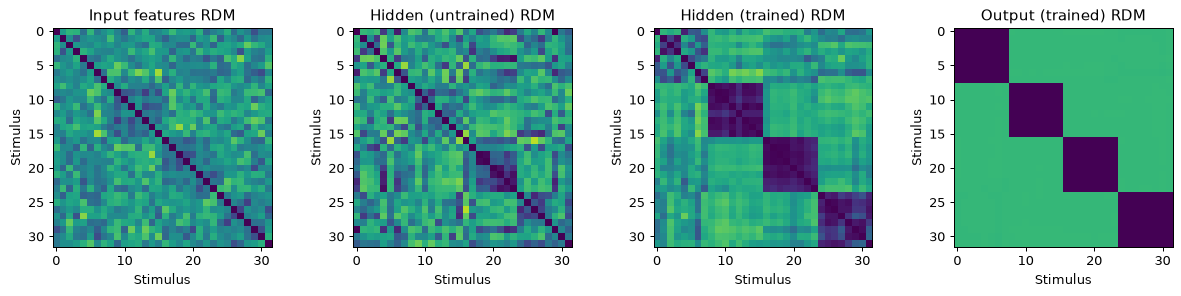

In [7]:
layers = {"Input features": X,
          "Hidden (untrained)": hidden_untrained,
          "Hidden (trained)": hidden_trained,
          "Output (trained)": output_trained}
regions = {"Early sensory": early_region, "Category-selective": categ_region}

fig, ax = plt.subplots(1, 4, figsize=(13.5, 3.2))
for a, (name, A) in zip(ax, layers.items()):
    a.imshow(rdm(A), cmap="viridis", vmin=0, vmax=2)
    a.set(title=name + " RDM", xlabel="Stimulus", ylabel="Stimulus")
fig.tight_layout()

iu = np.triu_indices(n_stim, k=1)                  # off-diagonal entries only
print(f"{'':>20s}  {'Early sensory':>14s}  {'Category-select.':>16s}")
rsa = np.zeros((4, 2))
for i, (lname, A) in enumerate(layers.items()):
    for j, (rname, B) in enumerate(regions.items()):
        rsa[i, j] = spearmanr(rdm(A)[iu], rdm(B)[iu]).statistic
    print(f"{lname:>20s}  {rsa[i,0]:14.2f}  {rsa[i,1]:16.2f}")

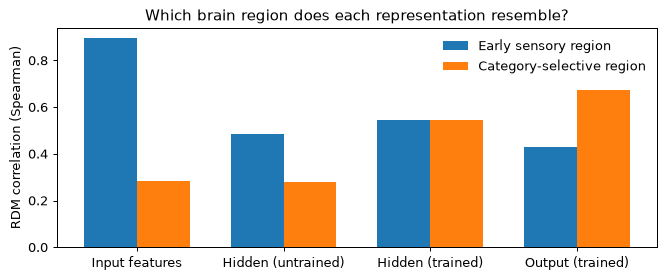

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
xpos = np.arange(4)
ax.bar(xpos - 0.18, rsa[:, 0], 0.36, label="Early sensory region", color="tab:blue")
ax.bar(xpos + 0.18, rsa[:, 1], 0.36, label="Category-selective region", color="tab:orange")
ax.set_xticks(xpos, list(layers))
ax.set(ylabel="RDM correlation (Spearman)",
       title="Which brain region does each representation resemble?")
ax.axhline(0, color="k", lw=0.5)
ax.legend(frameon=False)
fig.tight_layout()

**Interpretation.** The raw input features and the untrained hidden layer resemble the *early sensory* region — a random ReLU projection largely preserves the input's geometry — and neither shows much categorical structure. Training changes the picture, and the deeper into the network you look, the more categorical the geometry becomes: the trained hidden layer sits in between, while the trained output layer develops clear block structure and now resembles the *category-selective* region far more than the early one. The network has learned to *untangle* the categories, layer by layer. Nothing about the brain was used in training; brain-like geometry **emerged from optimizing task performance**, growing more categorical with depth. That is the essential logic of Yamins et al. (Figure 42.3): in CNNs optimized for object recognition, intermediate layers match V4 while top layers match IT cortex.

### Where the analogy breaks

Keep the toy nature of this demo in mind — it is built so the story comes out cleanly, and reality is messier:

- A high RDM correlation shows shared *geometry*, not shared *mechanism*: many different circuits (and objective functions) can produce the same similarity structure.
- Our "brain regions" were simulated with the very codes we tested for. Real analyses must guard against circularity, use held-out stimuli, and compare *many* candidate models, not two.
- Backpropagation as used here has no accepted biological implementation, and brains learn from far less data than modern models require.
- In real networks and real cortex alike, single units are entangled; category structure lives at the population level — which is why the multivariate methods of Chapters 37–41 are the right tools for reading it out.

**Going further:** swap the category-selective region for one coding a *graded* stimulus dimension and see which layer tracks it; add a second hidden layer and watch geometry change across depth; or make the TD task probabilistic and compare $\delta$ distributions across learning rates. Then return to the [chapter page](../ch42-ai-and-neuroscience.md) for the thought questions.